# Loan Approval Analysis (EDA)

This notebook presents a complete exploratory data analysis of the loan approval dataset with proper explanations and insights.

## Step 1: Import Libraries
These libraries are used for data analysis and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Step 2: Load Dataset
We load the dataset and preview first rows to understand structure.

In [2]:
df = pd.read_csv('loan_sanction_test.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


## Step 3: Data Overview
Understanding dataset structure, columns, and datatypes.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


### Statistical summary of numeric columns:

In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


## Step 4: Handling Missing Values
We fill missing values to ensure clean data for analysis.

In [7]:
# Fill categorical columns with mode
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill numeric columns with median
for col in df.select_dtypes(include=np.number):
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

## Step 5: Univariate Analysis
Analyzing individual variables.

### Histogram
Shows distribution of numeric variables.

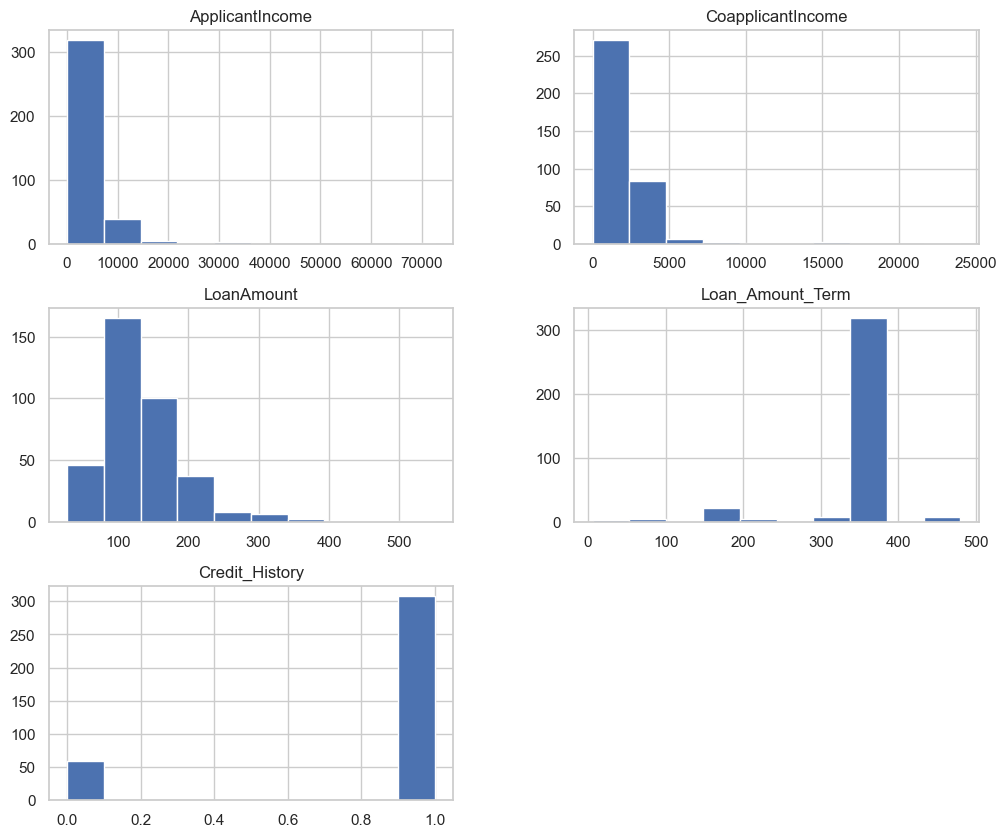

In [8]:
df.hist(figsize=(12,10))
plt.show()

**Insight:** Most values are concentrated in certain ranges, indicating skewness in income and loan amount.

### Boxplot
Used to detect outliers.

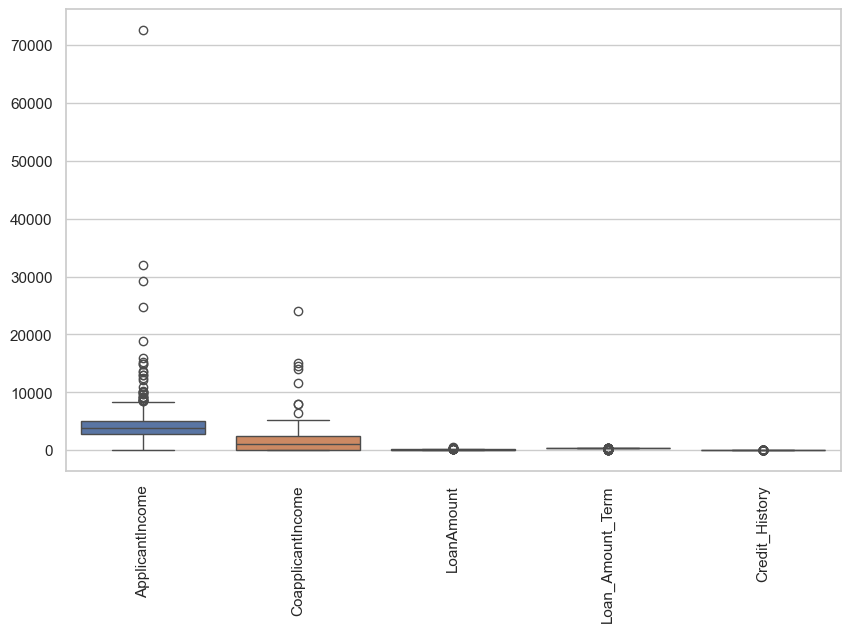

In [9]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

**Insight:** Presence of outliers in LoanAmount and ApplicantIncome.

### Bar Chart (Gender Distribution)

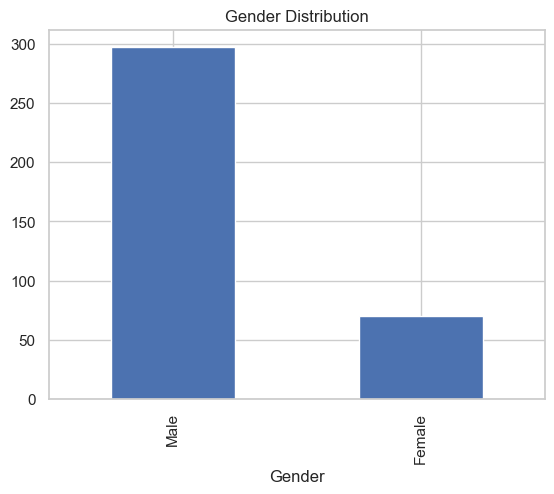

In [13]:
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

**Insight:** Shows how many loans are approved vs rejected.

### Pie Chart (Property Area Distribution)

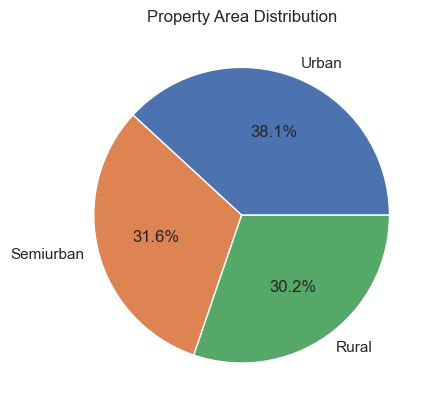

In [24]:
df['Property_Area'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Property Area Distribution")
plt.ylabel('')
plt.show()

## Step 6: Bivariate Analysis
Analyzing relationships between two variables.

### Scatter Plot

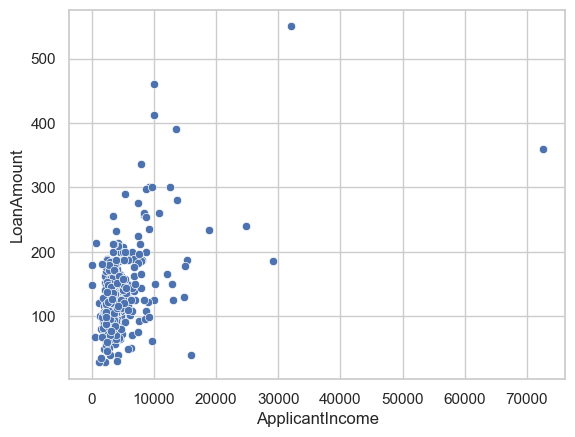

In [14]:
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', data=df)
plt.show()

**Insight:** Higher income applicants tend to request higher loan amounts.

### Boxplot (Gender vs Income)

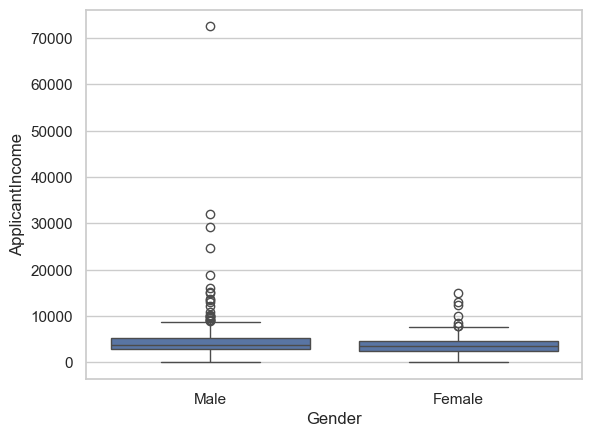

In [17]:
sns.boxplot(x='Gender', y='ApplicantIncome', data=df)
plt.show()

**Insight:** Males generally have higher income.

## Step 7: Multivariate Analysis
Analyzing multiple variables together.

### Correlation Heatmap

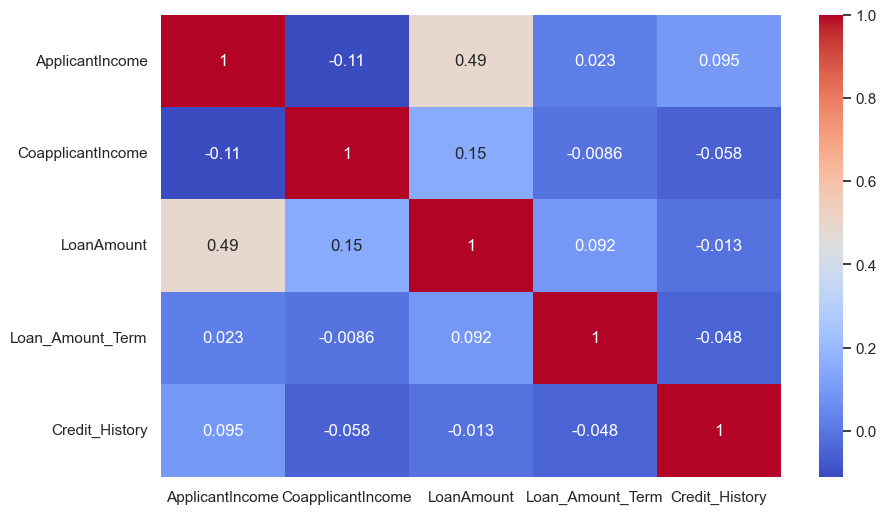

In [19]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

**Insight:** Shows relationships between variables like income and loan amount.

### Stacked Bar Chart

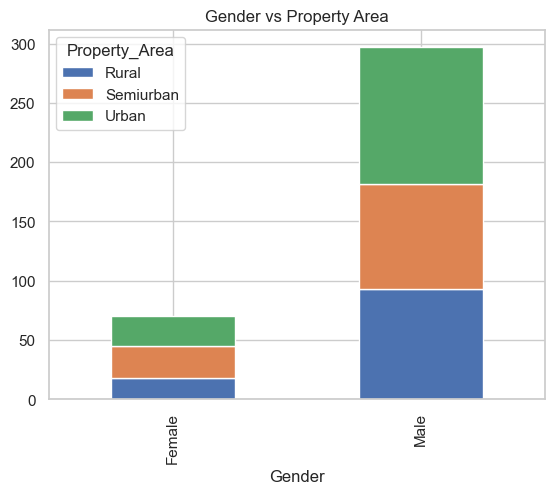

In [23]:
pd.crosstab(df['Gender'], df['Property_Area']).plot(kind='bar', stacked=True)
plt.title("Gender vs Property Area")
plt.show()

**Insight:** Urban property area has the highest number of applicants, with a higher proportion of male applicants compared to females

## Step 8: Conclusion

- Loan approval is influenced by applicant income and financial factors.
- Dataset contains some outliers which may impact decisions.
- Certain categories show higher approval rates.
- Correlation analysis reveals moderate relationships between financial variables.